# Quickstart

## Packages

Install additional packages required to run this vignette.

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import plotnine as pn
import decoupler as dc
import numpy as np

import partipy as pt
from partipy.datasets import load_hepatocyte_data_2

## Data

First, we need to download some single-cell data. Here, we will use mouse hepatocyte profiles by scRNA-seq from [1]. In this study, the authors found that approximately 50% of liver genes exhibit significant zonation, including non-monotonic expression patterns that peak in mid-lobule layers.  

**References**  
[1] Halpern, K. B. et al. Single-cell spatial reconstruction reveals global division of labour in the mammalian liver. *Nature* **542**, 352–356 (2017).

In [2]:
adata = load_hepatocyte_data_2()
adata

AnnData object with n_obs × n_vars = 1999 × 8354
    obs: 'cell_type', 'zone', 'run_id', 'time_point', 'UMAP_X', 'UMAP_Y'

## Preprocessing

Before conducting archetypal analysis (AA) on single-cell RNA-seq data, it is benefical to reduce the dimensionality of the data. To achieve this, we first scale the counts across all cells to a common value, followed by log normalization. Next, we identify highly variable genes and then apply principal component analysis using only those highly variable genes. We use `scanpy` for all these steps.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


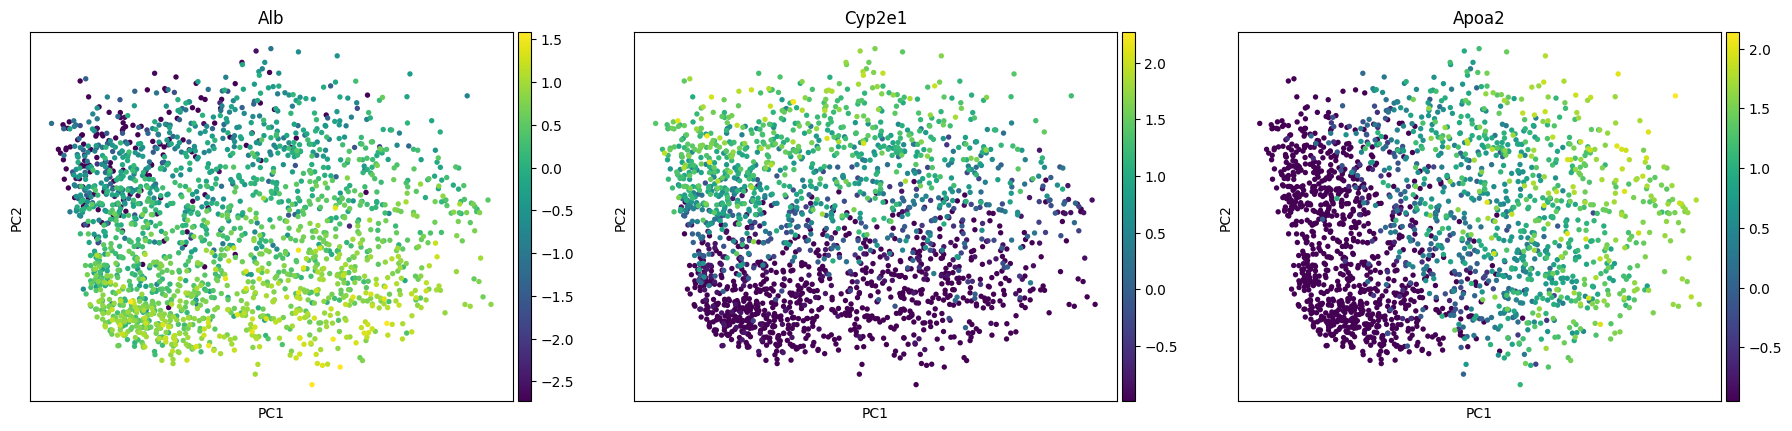

In [3]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable")
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10)
sc.pl.pca_scatter(adata, color=["Alb", "Cyp2e1", "Apoa2"])

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. The plot indicates that the gain in explained variance becomes negligible beyond the sixth principal component.

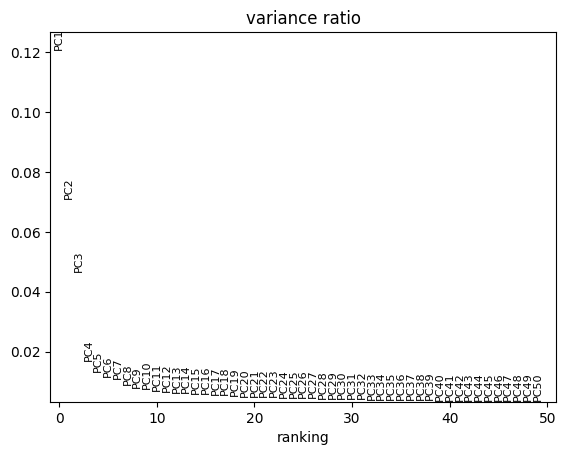

In [4]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

We store this setting in the adata.uns slot using the utility function `set_obsm`.

In [5]:
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=3)

## Choosing the Number of Archetypes

Now, we are ready to perform archetypal analysis, but the key question remains: how many archetypes should be used?

There is no definitive ground truth for this choice, but several heuristics can guide the decision. One approach is to evaluate how much variance is explained by different numbers of archetypes.

The function `var_explained_aa()` takes the reduced PCA data and computes the explained variance across a range of archetypes (from `min_k` to `max_k`). By default, this function utilizes all available CPU cores, as indicated by the `n_jobs` argument, which is set to `-1`.

Additionally the function `var_explained_aa()` computes an information criteria which was suggested by Suleman, A., 2017. Validation of archetypal analysis, in: 2017 IEEE International Conference on Fuzzy Systems (FUZZ-IEEE) pp. 1–6. https://doi.org/10.1109/FUZZ-IEEE.2017.8015385


The results are stored in `adata.uns["AA_metrics"]` and can be effectively visualized using plot_var_explained_aa(). The plot suggests that a reasonable choice for the number of archetypes is 4 as the additional explained variance becomes negligible beyond this point.

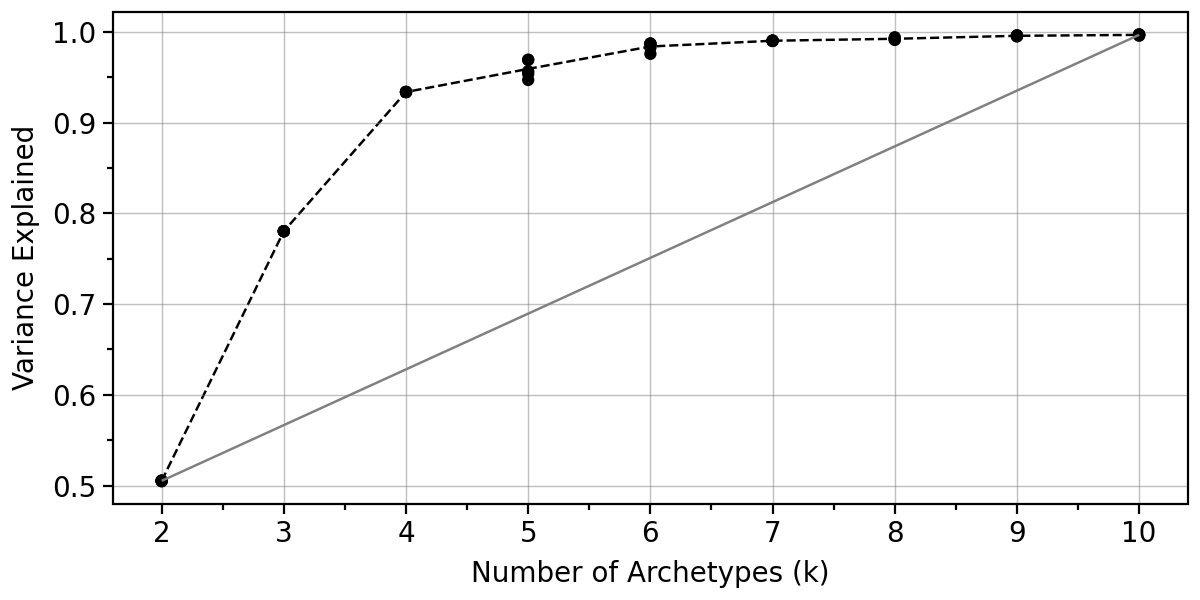

In [6]:
pt.compute_selection_metrics(adata=adata, min_k=2, max_k=10)
pt.plot_var_explained(adata)

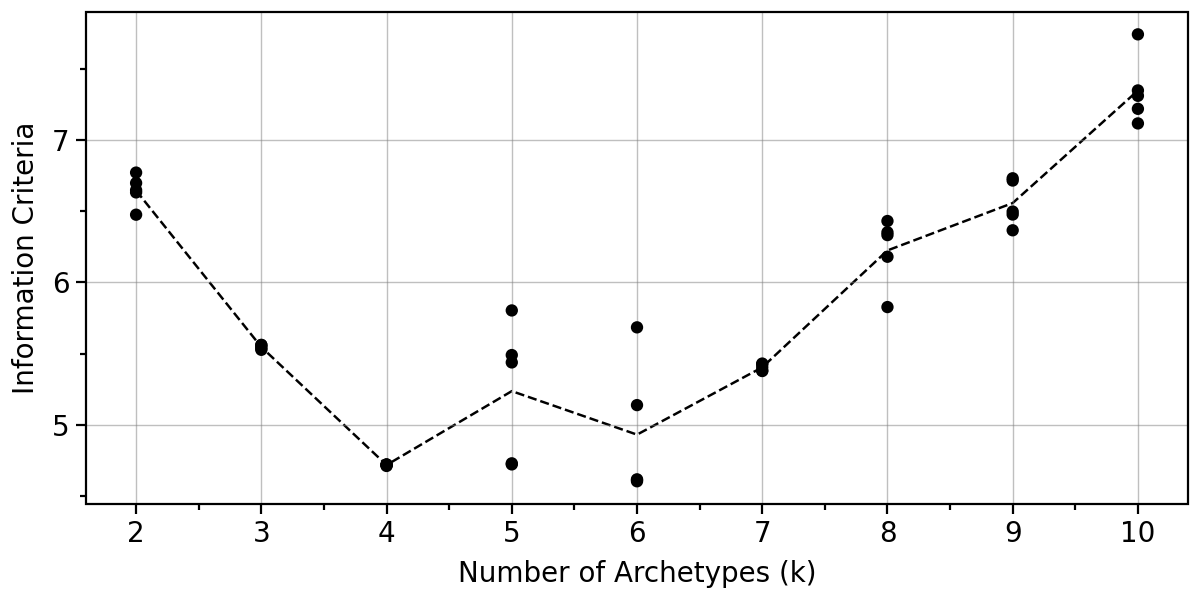

In [7]:
pt.plot_IC(adata)

An important consideration is whether the positions of the archetypes remain stable for a given number of archetypes. To assess this, we apply bootstrapping and perform Archetypal Analysis (AA) on resampled datasets.

By default, this function utilizes all available CPU cores, as specified by the `n_jobs` argument, which is set to `-1`. The results are stored in `adata.uns["AA_bootstrap"]` and can be visualized using `pt.plot_bootstrap_variance(adata)`.

As hinted to above, this result also suggest that 4 archetypes are highly stable.

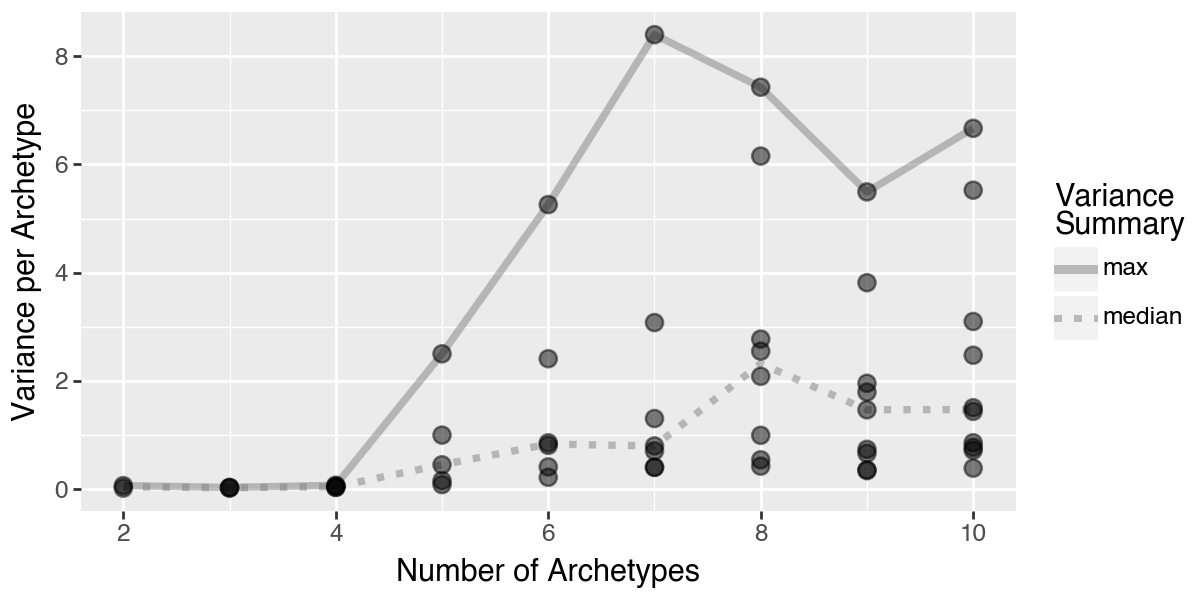

In [8]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=range(2, 11))
pt.plot_bootstrap_variance(adata)

## Archetypal Analysis

To compute the archetypes, we can simply use the `compute_archetypes` function. There are many optimization parameters which we describe in more detail in the vignette about [Archetypal Analysis](https://partipy.readthedocs.io/en/latest/notebooks/archetypal_analysis.html).

To get a feeling for the archetypes we might plot the polytope on first two dimensions. However, note that we actually fitted the polytope in a higher dimensional space.

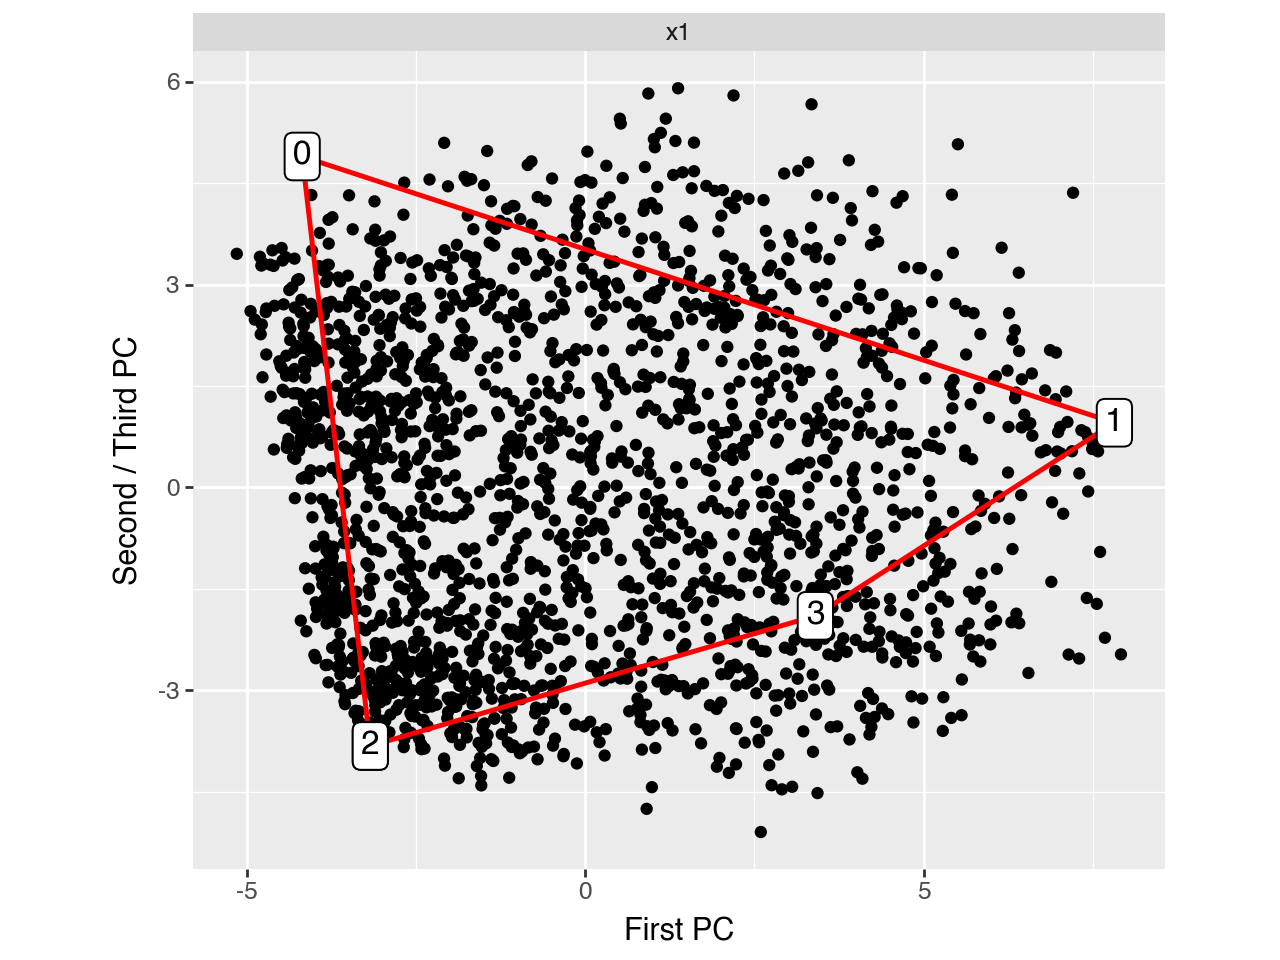

In [9]:
pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False)
    
pt.plot_archetypes_2D(adata=adata)

For a given $k$ we can also visually asses the bootstrap stability using `pt.plot_bootstrap_2D(adata)` for the first two principal components and `pt.plot_bootstrap_3D(adata)` for the first three.

Since Plotly does not render properly when exporting Jupyter notebooks, we will use only the 2D scatter plot here.

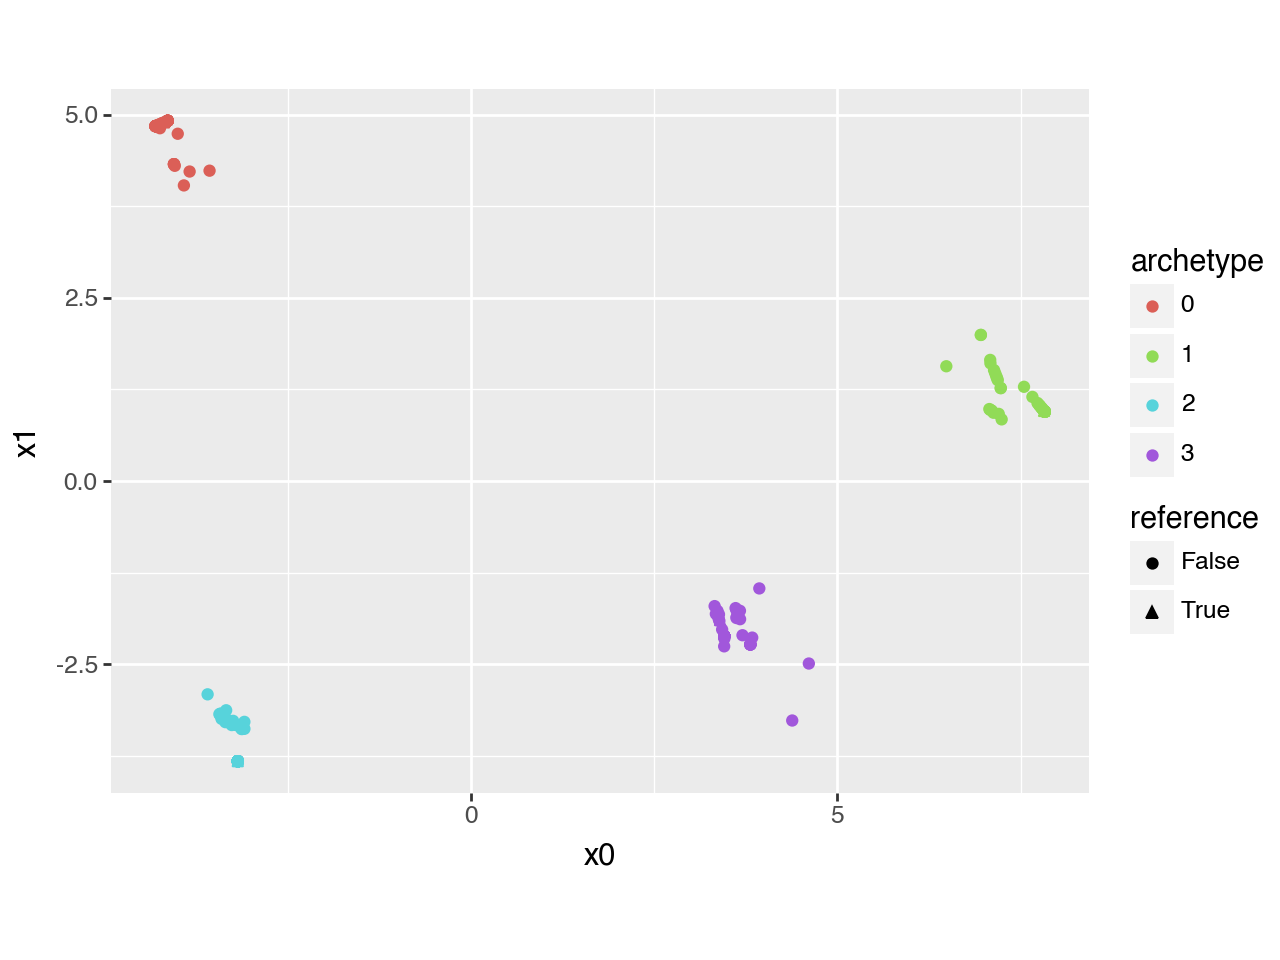

In [10]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=range(2, 11))

#pt.plot_bootstrap_3D(adata, n_archetypes=4)
pt.plot_bootstrap_2D(adata, n_archetypes=4)

We can also perform this different number of archetypes, to asses the stability if we were to change the number of archetypes.

Below, we will focus on the archetype that is enriched in detoxification functions.

In [11]:
arch_idx = 0

## Characterizing Archetypes

To better understand the archetypes, we aim to obtain the characteristic gene expression profile for each one.

We begin by computing the archetypal weights using the `compute_archetype_weights()` function, which assigns each cell a weight for each archetype based on its proximity to the archetype in the reduced space.

Next, we generate a the characteristic expression profile for each archetype using weighted averaging. This is achieved with the `compute_archetype_expression()` function, which aggregates expression data across cells according to their archetypal contributions.

To better illustrate this, we visualize the weights for archetype **0**  using the `plot_2D_adata()` function, highlighting the extent to which each cell is associated with it.

Applied length scale is 3.2452696839439295.


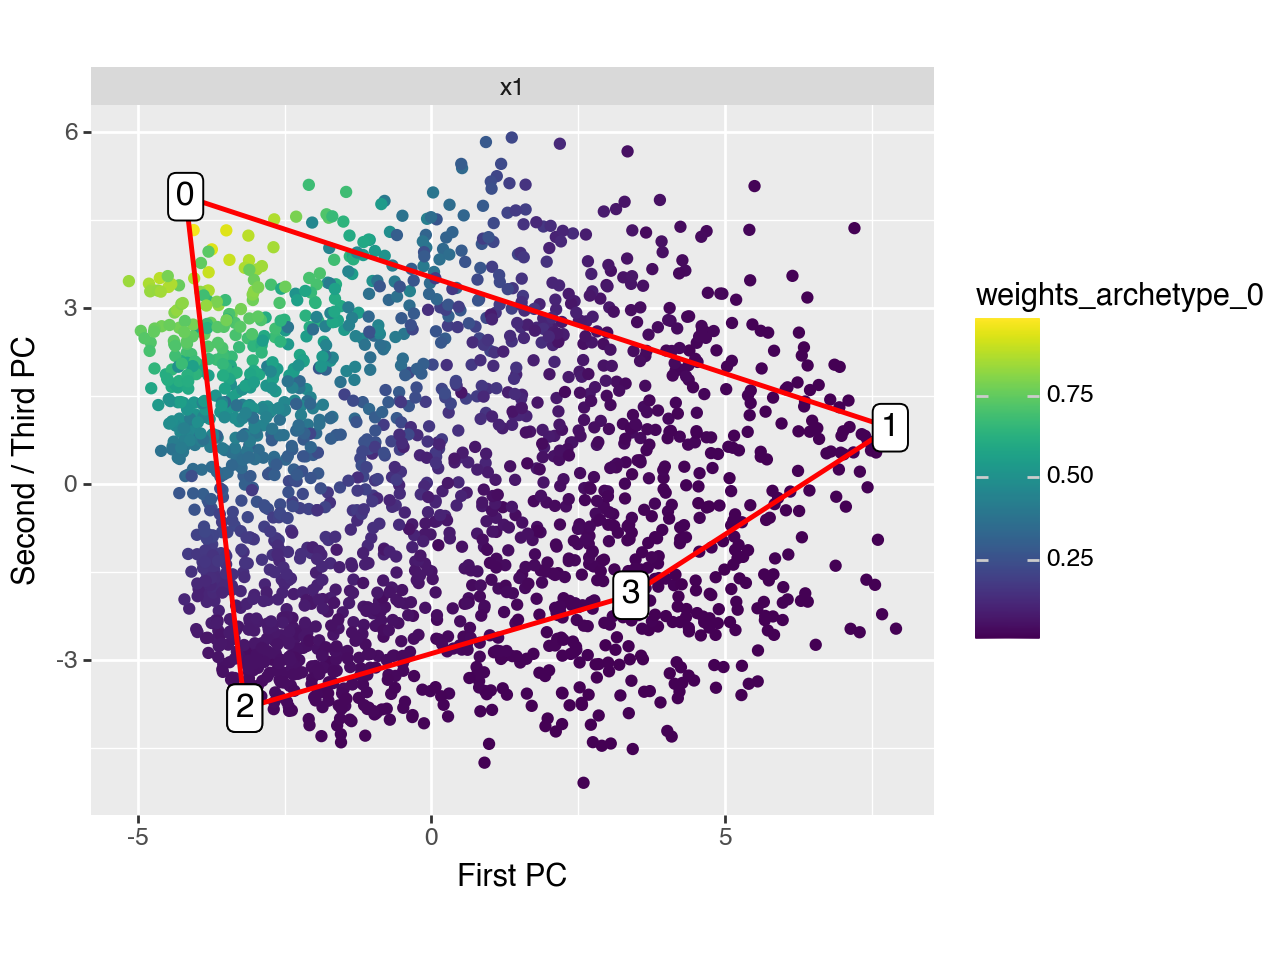

In [12]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

adata.obs[f"weights_archetype_{arch_idx}"] = adata.obsm["cell_weights"][:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}")

Now we can use the characteristic gene expression profile to see which genes are relatively important for each archetype. As promised above, archetype 0 is characterized by high expression of Cytochrome P450 enzymes which are important for detoxification.

In [13]:
archetype_expression.T.sort_values(arch_idx, ascending=False).head(10)

,0,1,2,3
Cyp2e1,0.792724,-0.249668,-0.540118,-0.192438
Oat,0.698818,-0.282437,-0.334897,-0.231355
Cyp2c29,0.662457,-0.255316,-0.490248,-0.051990
Rgn,0.656587,-0.220104,-0.321856,-0.322574
Cyp2c50,0.626024,-0.205990,-0.416417,-0.124198
Cyp3a11,0.612912,-0.401555,-0.301611,-0.155223
Csad,0.612066,-0.174892,-0.247012,-0.355207
Cyp4a10,0.598974,-0.309703,-0.255126,-0.166968
Rpl41,0.594341,-0.141460,0.015750,-0.849214
Rpl37,0.588502,-0.033465,-0.023088,-0.764399


We can also use the characteristic gene expression profiles of each archetype to perform enrichment analysis with decoupler. Here, we focus on Reactome pathways because we are interested in metabolic processes.

In [14]:
database = "reactome_pathways"
min_genes_per_pathway = 5
max_genes_per_pathway = 80

# dc.op.resource("SIGNOR", organism="mouse")
msigdb_raw = dc.op.resource("MSigDB")
msigdb = msigdb_raw[msigdb_raw["collection"]==database]
selection_vec = ~ np.array(["RESPONSE_TO" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["GENE_EXPRESSION" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["SARS_COV" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["STIMULATED_TRANSCRIPTION" in s for s in msigdb["geneset"]])
msigdb = msigdb.loc[selection_vec, :].copy()
msigdb = msigdb[~msigdb.duplicated(["geneset", "genesymbol"])].copy()
genesets_within_min = (msigdb.value_counts("geneset") >= min_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_within_max = (msigdb.value_counts("geneset") <= max_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_to_keep = list(set(genesets_within_min) & set(genesets_within_max))
msigdb = msigdb.loc[msigdb["geneset"].isin(genesets_to_keep), :].copy() # removing small gene sets
msigdb_mouse = dc.op.translate(msigdb, target_organism="mouse") # requires decoupler >= 2.0.0
msigdb_mouse = msigdb_mouse.drop_duplicates()
msigdb_mouse = msigdb_mouse.rename(columns={"geneset": "source", "genesymbol": "target"})

acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=msigdb_mouse,
                                         verbose=False)

acts_ulm_est.iloc[:4, :4]

,REACTOME_2_LTR_CIRCLE_FORMATION,REACTOME_ABACAVIR_ADME,REACTOME_ABC_TRANSPORTERS_IN_LIPID_HOMEOSTASIS,REACTOME_ABERRANT_REGULATION_OF_MITOTIC_EXIT_IN_CANCER_DUE_TO_RB1_DEFECTS
0,0.360084,0.377992,-1.290860,-0.052320
1,0.033771,-1.131579,1.441092,0.191714
2,-0.524161,0.378556,-1.795523,-0.126125
3,0.660268,-0.633592,2.731305,0.152135


We can then extract the top $x$ (here $x=10$) processes per archetype using 
`extract_enriched_processes()`. Focusing on Archetype 0 this revals Reactome pathways related to xenobiotics (including pathways related to oxidiaton and functionalization).

In [15]:
top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                              pval=acts_ulm_est_p, 
                                              order="desc", 
                                              n=10,
                                              p_threshold=0.05)

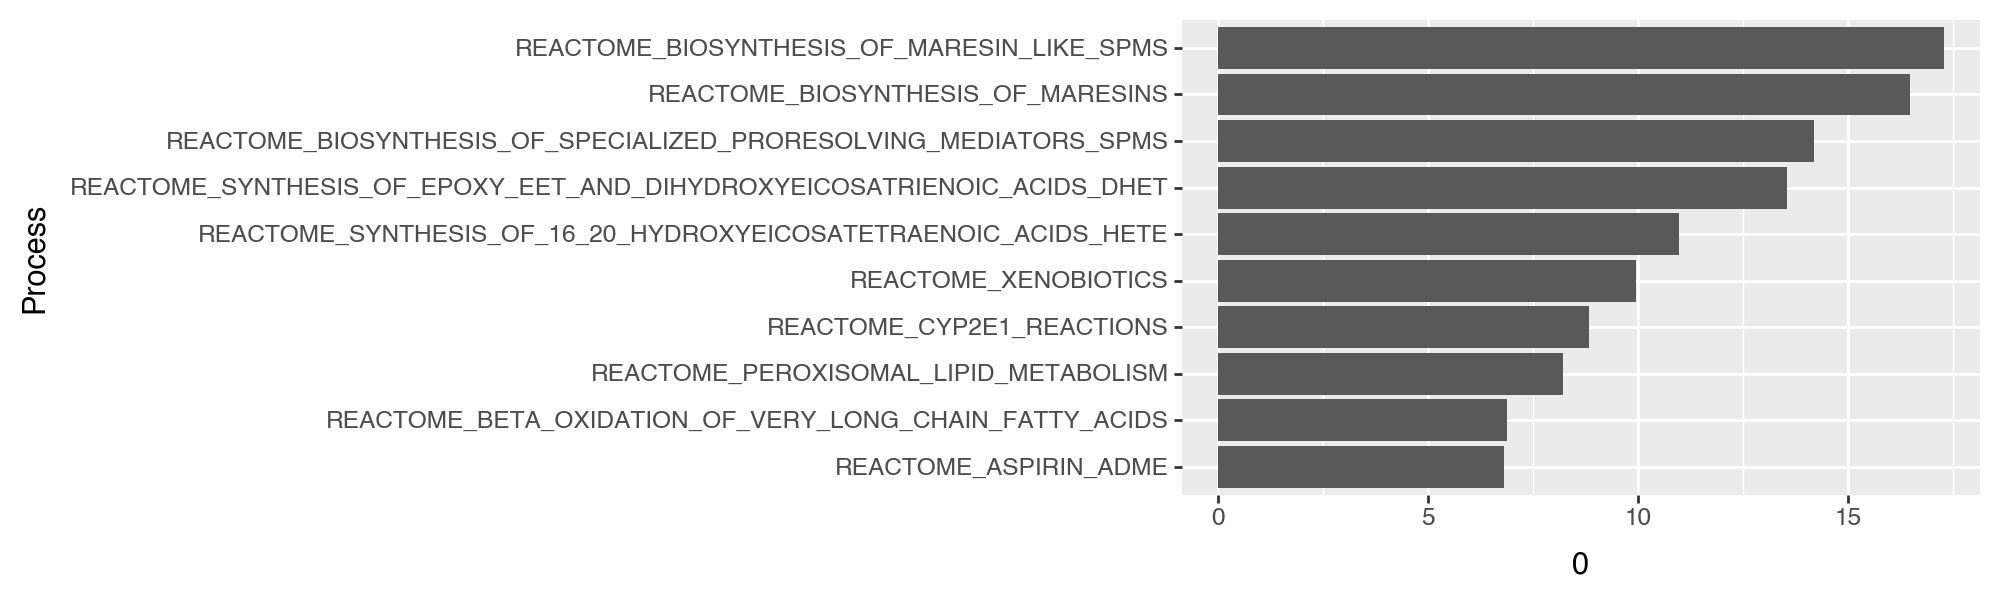

In [16]:
top_processes[arch_idx]["Process"] = pd.Categorical(
    top_processes[arch_idx]["Process"],
    categories=top_processes[arch_idx].sort_values(f"{arch_idx}", ascending=True)["Process"].to_list()
)

(pn.ggplot(top_processes[arch_idx])
 + pn.geom_col(pn.aes(x="Process", y=f"{arch_idx}"))
 + pn.coord_flip()
 + pn.theme(figure_size=(10, 3)))

Then, we can decoupler's leading edge function to check for example which genes have a high weight for our archetype of interest, and are in the gene set for "REACTOME_XENOBIOTICS".

['Cyp2e1' 'Cyp2c29' 'Cyp2c50' 'Cyp1a2' 'Cyp2c37' 'Cyp2a5' 'Cyp2c38' 'Ahr']


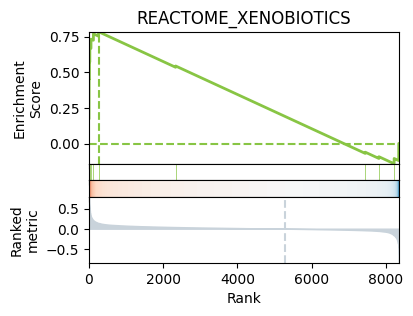

In [17]:
df = archetype_expression.T.copy()
df.columns = df.columns.astype(str)
_, le = dc.pl.leading_edge(
    df = df,
    net = msigdb_mouse,
    stat = str(arch_idx),
    name = "REACTOME_XENOBIOTICS"
)
print(le)

## Spatial Enrichment

As in (Adler M., et al. 2019, Continuum of Gene-Expression Profiles Provides Spatial Division of Labor within a Differentiated Cell Type), we want to look where the archetypes locate in the tissue.

To that end we download a single-cell spatial data set from the liver from https://info.vizgen.com/mouse-liver-data (Vizgen MERFISH Mouse Liver Map January 2022). In particular we only need to download from `Liver1Slice1` the files `"cell_by_gene.csv", "cell_metadata.csv"` and place those in the folder `Liver1Slice1` in `data`.

Then, to quantify to which archetype any given cell is close to, we compute the enrichment of the archetype gene expression signatures in each cells' gene expression profile.

In [18]:
import sys
!{sys.executable} -m pip install --quiet squidpy

In [19]:
archetype_expression

,Mrpl15,Lypla1,Tcea1,Atp6v1h,Rb1cc1,Pcmtd1,Rrs1,Adhfe1,Vcpip1,Sgk3,...,mt-Co3,mt-Nd3,mt-Nd4l,mt-Nd4,mt-Nd5,mt-Nd6,mt-Cytb,Vamp7,AC149090.1,CAAA01118383.1
0,-0.004389,0.057427,0.075832,0.030303,-0.014773,0.079947,-0.008569,0.130077,-0.025476,0.043123,...,-0.267713,-0.037735,-0.098343,-0.282511,-0.078674,0.008114,-0.355522,0.017464,-0.103511,0.011220
1,0.169951,-0.092879,-0.062810,-0.038762,-0.014972,-0.106777,-0.016629,-0.130023,-0.043854,0.017837,...,-0.308374,-0.151062,-0.153978,-0.187513,-0.042195,-0.110407,-0.051319,-0.026842,0.002220,0.047385
2,-0.067538,0.015574,-0.015195,-0.017582,0.041366,0.097683,-0.005995,0.008468,-0.005829,-0.004644,...,-0.004129,0.063458,-0.056468,0.174532,-0.035328,0.033739,0.067593,0.007895,0.037112,-0.012822
3,0.006784,-0.082047,-0.138740,-0.060857,-0.007164,-0.160560,-0.031094,-0.153095,0.014553,-0.050513,...,0.830644,0.131299,0.384971,0.371257,0.221049,-0.003198,0.578438,-0.041099,-0.007649,-0.045908


/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


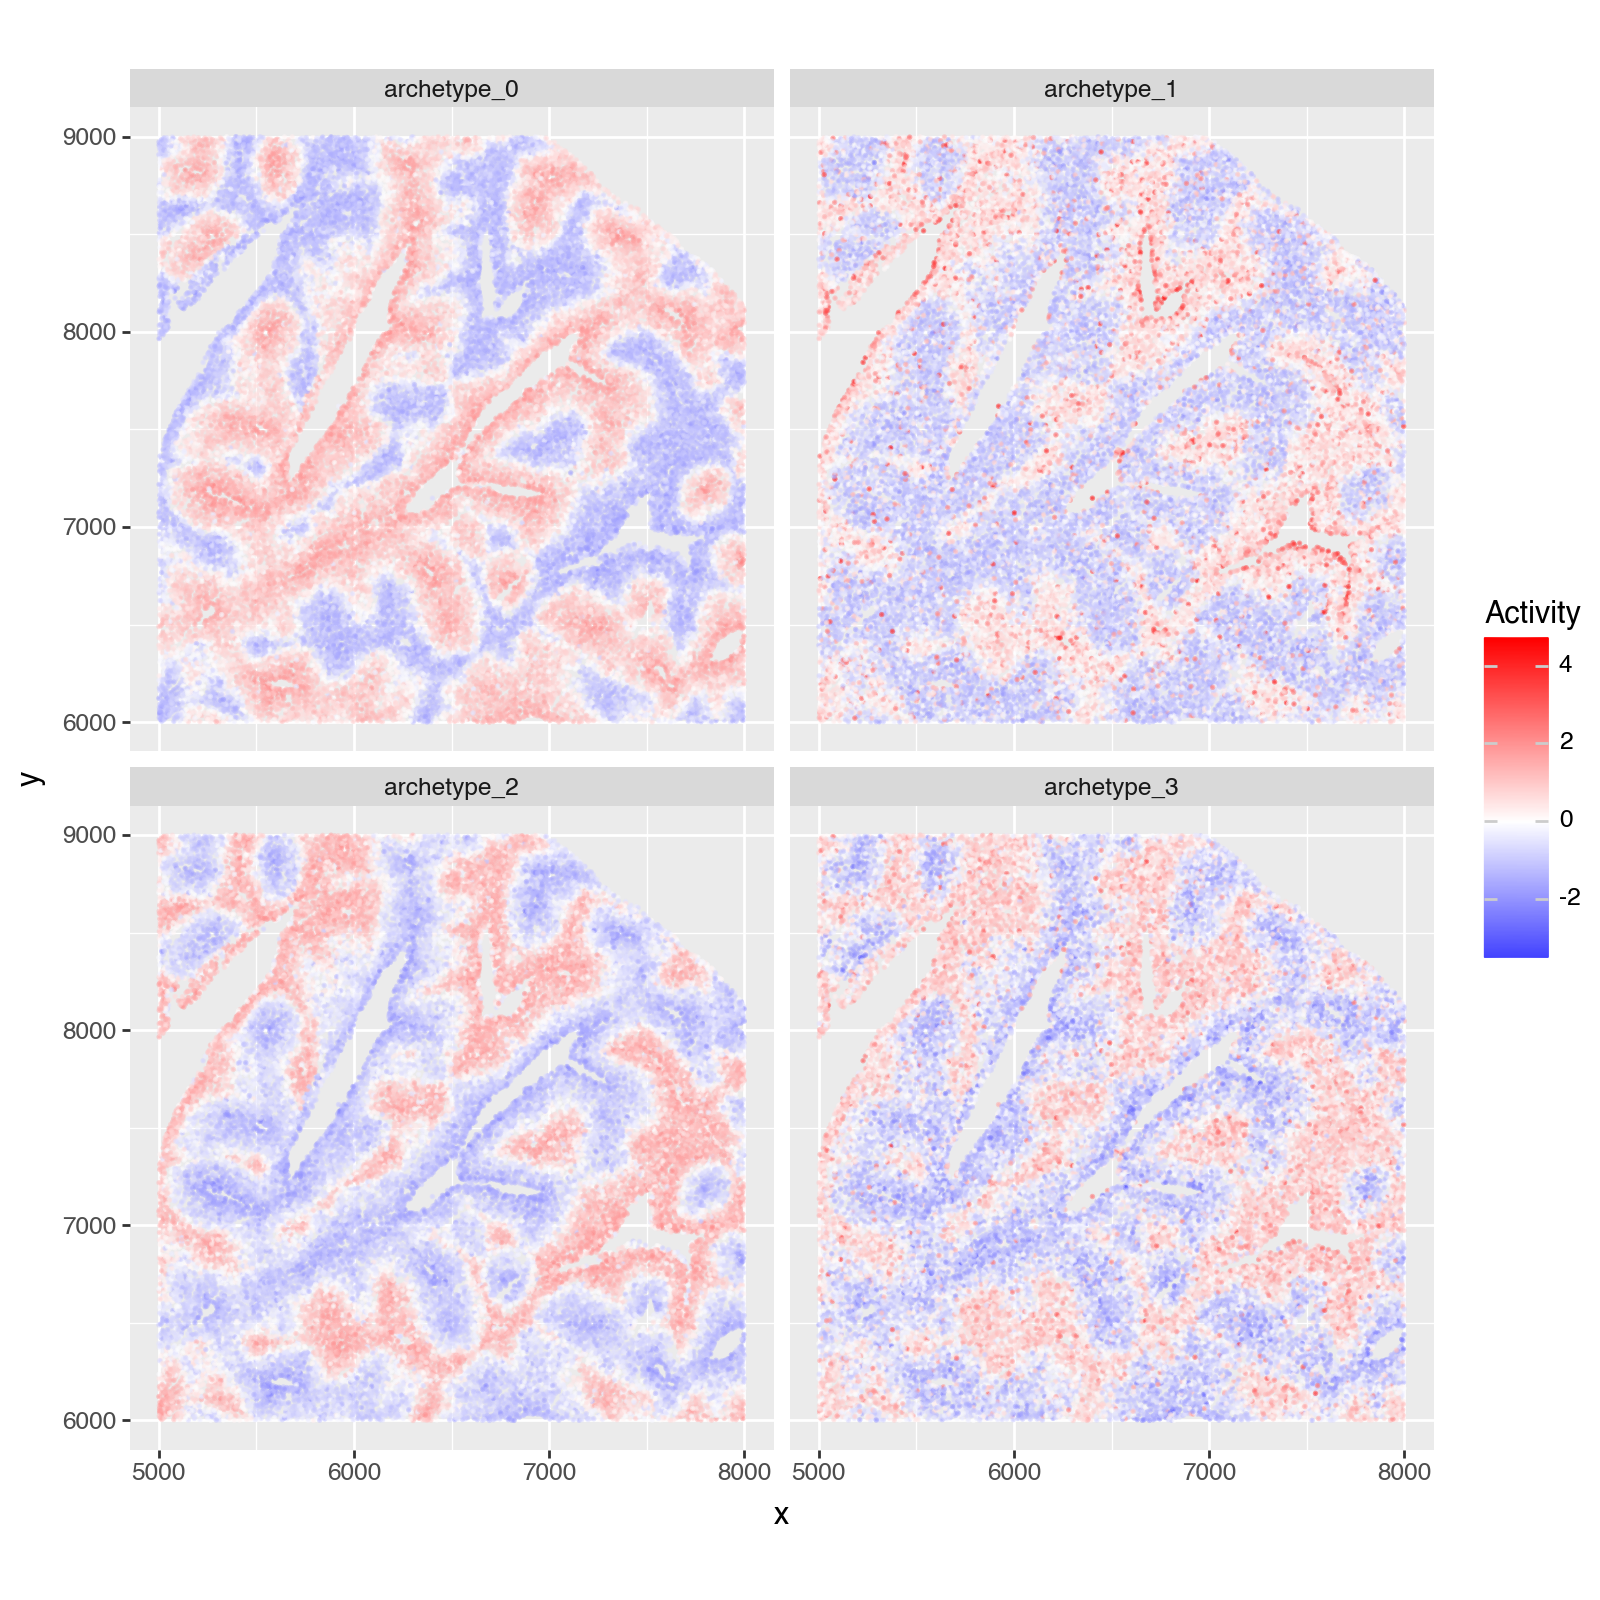

In [20]:
# only run if the data has actually been downloaded
if (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_by_gene.csv").exists() and (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_metadata.csv").exists():
    import squidpy as sq
    vizgen_adata = sq.read.vizgen(
        "./data/Liver1Slice1",
        counts_file="Liver1Slice1_cell_by_gene.csv",
        meta_file="Liver1Slice1_cell_metadata.csv",
    )
    vizgen_adata = vizgen_adata[:, vizgen_adata.var.index.isin(archetype_expression.columns.to_list())].copy()
    vizgen_adata = vizgen_adata[vizgen_adata.X.sum(axis=1).A1 > 200, :].copy()
    sc.pp.normalize_total(vizgen_adata)
    sc.pp.log1p(vizgen_adata)

    # create weights based on archetype expression profile
    archetype_expression_weights = (archetype_expression[vizgen_adata.var.index].copy()
                                    .reset_index(names="archetype")
                                    .melt(id_vars="archetype", value_name="weight", var_name="gene")
                                    )
    archetype_expression_weights = archetype_expression_weights.rename(columns={"archetype": "source", "gene": "target"})

    # compute the enrichment of the archetype gex profiles in the gex profiles of each cell
    dc.mt.ulm(data=vizgen_adata, net=archetype_expression_weights, verbose=False)

    # plotting one part
    plotting_df = vizgen_adata.obsm["score_ulm"].copy()
    plotting_df.columns = ["archetype_" + idx for idx in plotting_df.columns]
    plotting_df = plotting_df - plotting_df.mean()
    plotting_df = plotting_df / plotting_df.std()
    plotting_df["x"] = vizgen_adata.obsm["spatial"][:, 0]
    plotting_df["y"] = vizgen_adata.obsm["spatial"][:, 1]

    width = 3_000
    x_low = 5_000
    y_low = 6_000
    x_high = x_low + width
    y_high = y_low + width
    plotting_df = plotting_df.loc[(plotting_df["x"] > x_low) & (plotting_df["x"] < x_high) & (plotting_df["y"] > y_low) & (plotting_df["y"] < y_high)]

    plotting_df = plotting_df.melt(id_vars=["x", "y"], value_name="score", var_name="archetype")
    p = (pn.ggplot(plotting_df) 
        + pn.geom_point(pn.aes(x="x", y="y", color="score"), size=0.1, alpha=0.5) 
        + pn.scale_color_gradient2(low="blue", mid="white", high="red", midpoint=0)
        + pn.facet_wrap(facets="archetype", nrow=2, ncol=2)
        + pn.coord_equal() 
        + pn.theme(figure_size=(8, 8)) 
        + pn.labs(x="x", y="y", color="Activity")
        )
    p.show()

## Session Info

In [21]:
import session_info2
print(session_info2.session_info(dependencies=True))

pandas	2.2.3
scanpy	1.11.2
plotnine	0.14.5
decoupler	2.0.2
numpy	2.2.6
partipy	0.0.1
anndata	0.11.4
squidpy	1.6.5
----	----
future	1.0.0
wrapt	1.17.2
natsort	8.4.0
docrep	0.3.2
xarray-schema	0.0.3
prompt_toolkit	3.0.51
imageio	2.37.0
jaraco.functools	4.0.1
parso	0.8.4
pyparsing	3.2.3
jupyter_client	8.6.3
marsilea	0.5.3
pybiomart	0.2.0
jaraco.context	5.3.0
PyYAML	6.0.2
xgboost	3.0.2
cloudpickle	3.1.1
statsmodels	0.14.4
matplotlib-inline	0.1.7
h5py	3.13.0
Deprecated	1.2.18
idna	3.10
pyzmq	26.4.0
zarr	2.18.7
toolz	1.0.0
tqdm	4.67.1
param	2.2.0
pillow	11.2.1
dask-image	2024.5.3
seaborn	0.13.2
numba	0.61.2
multipledispatch	1.0.0 (0.6.0)
xarray-dataclasses	1.9.1
six	1.17.0
tornado	6.5.1
kiwisolver	1.4.8
appnope	0.1.4
xarray-spatial	0.4.0
pyproj	3.7.1
matplotlib	3.10.3
ipython	9.2.0
certifi	2025.4.26 (2025.04.26)
igraph	0.11.8
python-dateutil	2.9.0.post0
packaging	25.0
cattrs	24.1.3
dask	2024.11.2
legendkit	0.3.5
jupyter_core	5.8.1
more-itertools	10.7.0
requests	2.32.3
pyct	0.5.0
session-info